In [4]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import sklearn
import torch
from torchvision import transforms
# !pip install torchmetrics   # uncomment if not installed
import torchmetrics
from torchmetrics.classification import BinaryAccuracy, BinaryPrecision, BinaryRecall, BinaryF1Score


## Prerequisites

Before running this notebook locally, make sure you have:
1. Installed dependencies: `uv sync` from the project root
2. Downloaded the FracAtlas dataset and placed it at `FracAtlas/` in the project root
3. Run `fractured_augmentation.ipynb` (in `notebook/`) to generate augmented images and organize the YOLO dataset structure under `notebook/datasets/dataset/`


In [6]:
local_path = "../FracAtlas/dataset.csv"
df = pl.read_csv(local_path)
df.head()


image_id,hand,leg,hip,shoulder,mixed,hardware,multiscan,fractured,fracture_count,frontal,lateral,oblique
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""IMG0000000.jpg""",0,1,0,0,0,0,1,0,0,1,1,0
"""IMG0000001.jpg""",0,1,0,0,0,0,1,0,0,1,1,0
"""IMG0000002.jpg""",0,1,0,0,0,0,1,0,0,1,1,0
"""IMG0000003.jpg""",0,1,0,0,0,0,1,0,0,0,1,1
"""IMG0000004.jpg""",0,1,0,0,0,0,1,0,0,0,1,1


# Load augmented train, validation, test paths

In [7]:
from pathlib import Path

split_root = Path("../notebook/datasets/dataset")
labels_cache_csv = split_root / "split_labels_cache.csv"

dataset_train_dir = split_root / "train"
dataset_valid_dir = split_root / "valid"
dataset_test_dir = split_root / "test"

for required_dir in [
    dataset_train_dir / "images", dataset_train_dir / "labels",
    dataset_valid_dir / "images", dataset_valid_dir / "labels",
    dataset_test_dir / "images", dataset_test_dir / "labels",
]:
    if not required_dir.exists():
        raise FileNotFoundError(f"Missing required directory: {required_dir}")

def build_split_cache(split_root: Path, output_csv: Path) -> pl.DataFrame:
    image_exts = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
    rows = []

    for split_name in ["train", "valid", "test"]:
        split_dir = split_root / split_name
        images_dir = split_dir / "images"
        labels_dir = split_dir / "labels"

        for label_file in sorted(labels_dir.glob("*.txt")):
            stem = label_file.stem
            image_path = None

            for ext in image_exts:
                candidate = images_dir / f"{stem}{ext}"
                if candidate.exists():
                    image_path = candidate
                    break

            if image_path is None:
                continue

            content = label_file.read_text(encoding="utf-8").strip()
            label = 1 if content else 0
            rows.append({
                "split": split_name,
                "image_id": stem,
                "paths": str(image_path),
                "fractured": label,
            })

    cache_df = pl.DataFrame(rows)
    cache_df.write_csv(output_csv)
    return cache_df

if labels_cache_csv.exists():
    cache_df = pl.read_csv(labels_cache_csv)
else:
    cache_df = build_split_cache(split_root, labels_cache_csv)

train_df = cache_df.filter(pl.col("split") == "train")
validation_df = cache_df.filter(pl.col("split") == "valid")
test_df = cache_df.filter(pl.col("split") == "test")

train_paths = train_df["paths"]
validation_paths = validation_df["paths"]
test_paths = test_df["paths"]

train_labels = train_df["fractured"]
validation_labels = validation_df["fractured"]
test_labels = test_df["fractured"]

train_label_tensor = torch.tensor(train_labels.to_list(), dtype=torch.float32)
validation_label_tensor = torch.tensor(validation_labels.to_list(), dtype=torch.float32)
test_label_tensor = torch.tensor(test_labels.to_list(), dtype=torch.float32)

print(f"Loaded {len(cache_df)} rows from: {labels_cache_csv}")

Loaded 5805 rows from: /content/drive/MyDrive/STINTSYMCO1/datasets/dataset/split_labels_cache.csv


# Fracture Dataset Loader

In [8]:
from torch.utils.data import Dataset 
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

class FractureDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.paths)
    
    def __getitem__(self,index):
        img = Image.open(self.paths[index]).convert("RGB")
        img = self.transform(img)
        label = self.labels[index]
        return img, label

# Transform data with the required transformations of MobileNetV3

In [9]:
transform = transforms.Compose([
    transforms.Resize((232, 232)),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),                          
    transforms.Normalize([0.485, 0.456, 0.406],    
                         [0.229, 0.224, 0.225])   
])

# Batch Size = 32 to speed up training time

In [10]:
from torch.utils.data import DataLoader

use_cuda = torch.cuda.is_available()
num_workers = 2 if use_cuda else 0
pin_memory = use_cuda

train_dataset = FractureDataset(train_paths.to_list(), train_labels.to_list(), transform=transform)
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory
)

val_dataset = FractureDataset(validation_paths.to_list(), validation_labels.to_list(), transform)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory
)

test_dataset = FractureDataset(test_paths.to_list(), test_labels.to_list(), transform)
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory
)

print(f"CUDA available: {use_cuda} | num_workers={num_workers} | pin_memory={pin_memory}")

CUDA available: True | num_workers=2 | pin_memory=True


# Load MobileNetV3 and freeze all parameters except classifier. 
MobileNet was chosen as the pretrained model to fine-tune due to hardware limitations and cloud compute accessbility aka I used 4 google accounts in rotation in training my models in google colab.

In [11]:
from torchvision import models
import torch.nn as nn

model = models.mobilenet_v3_large(weights= models.MobileNet_V3_Large_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(model.classifier[0].in_features, 1) 
)

print("Trainable params:", sum(p.requires_grad for p in model.parameters()))

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 131MB/s]


Trainable params: 2


In [12]:
num_fractured = int((train_labels == 1).sum())
num_non_fractured = int((train_labels == 0).sum())
print(f"Train set class counts -> fractured: {num_fractured}, non-fractured: {num_non_fractured}")

Train set class counts -> fractured: 2295, non-fractured: 2696


Set Learning rate to 0.003 for the classifier

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

pos_weight = torch.tensor([num_non_fractured / num_fractured], device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)

print(f"Using device: {device} | pos_weight={pos_weight.item():.4f}")

Using device: cuda | pos_weight=1.1747


Double check cuda

In [14]:
model = model.to(device)
model_device = next(model.parameters()).device
print(f"Model device: {model_device}")

sample_images, sample_labels = next(iter(train_loader))
print(f"Batch before move -> images: {sample_images.device}, labels: {sample_labels.device}")
sample_images = sample_images.to(device)
sample_labels = sample_labels.to(device)
print(f"Batch after move  -> images: {sample_images.device}, labels: {sample_labels.device}")

assert model_device.type == device.type, "Model is not on the expected device."
assert sample_images.device.type == device.type, "Input batch is not on the expected device."

Model device: cuda:0
Batch before move -> images: cpu, labels: cpu
Batch after move  -> images: cuda:0, labels: cuda:0


In [15]:
def train_one_stage(model, train_loader, val_loader, optimizer, criterion, device, num_epochs=10, val_threshold=0.40, log_every=20):
    accuracy = BinaryAccuracy().to(device)
    precision = BinaryPrecision().to(device)
    recall = BinaryRecall().to(device)
    f1 = BinaryF1Score().to(device)
    scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

    history = {
        "train_loss": [], "train_acc": [], "train_precision": [], "train_recall": [], "train_f1": [],
        "val_loss": [], "val_acc": [], "val_precision": [], "val_recall": [], "val_f1": []
    }

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        total_train_batches = len(train_loader)

        accuracy.reset()
        precision.reset()
        recall.reset()
        f1.reset()

        for batch_idx, (images, labels) in enumerate(train_loader, start=1):
            images = images.to(device)
            labels = labels.to(device)
            labels_float = labels.float()
            labels_int = labels.long()

            optimizer.zero_grad()
            with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                outputs = model(images).flatten()
                loss = criterion(outputs, labels_float)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            batch_loss = loss.item()
            train_loss += batch_loss * images.size(0)
            train_probs = torch.sigmoid(outputs)
            preds = (train_probs >= val_threshold).long()

            accuracy.update(preds, labels_int)
            precision.update(preds, labels_int)
            recall.update(preds, labels_int)
            f1.update(preds, labels_int)

            if (batch_idx % log_every == 0) or (batch_idx == total_train_batches):
                print(
                    f"Epoch [{epoch+1}/{num_epochs}] "
                    f"Batch [{batch_idx}/{total_train_batches}] "
                    f"Batch Loss: {batch_loss:.4f}"
                )

        train_loss /= len(train_loader.dataset)
        train_acc = accuracy.compute().item()
        train_precision = precision.compute().item()
        train_recall = recall.compute().item()
        train_f1 = f1.compute().item()

        model.eval()
        val_loss = 0.0

        accuracy.reset()
        precision.reset()
        recall.reset()
        f1.reset()

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                labels_float = labels.float()
                labels_int = labels.long()

                with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                    outputs = model(images).flatten()
                    loss = criterion(outputs, labels_float)

                val_loss += loss.item() * images.size(0)
                val_probs = torch.sigmoid(outputs)
                preds = (val_probs >= val_threshold).long()

                accuracy.update(preds, labels_int)
                precision.update(preds, labels_int)
                recall.update(preds, labels_int)
                f1.update(preds, labels_int)

        val_loss /= len(val_loader.dataset)
        val_acc = accuracy.compute().item()
        val_precision = precision.compute().item()
        val_recall = recall.compute().item()
        val_f1 = f1.compute().item()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["train_precision"].append(train_precision)
        history["train_recall"].append(train_recall)
        history["train_f1"].append(train_f1)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_precision"].append(val_precision)
        history["val_recall"].append(val_recall)
        history["val_f1"].append(val_f1)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} Prec: {train_precision:.4f} Rec: {train_recall:.4f} F1: {train_f1:.4f} | "
            f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} Prec: {val_precision:.4f} Rec: {val_recall:.4f} F1: {val_f1:.4f} Thr: {val_threshold:.2f}"
        )

    return history

First Model, train classifier first
Validation threshold = 0.4 was chosen to increase recall to reduce false negatives

In [13]:

num_epochs = 10
history_stage1 = train_one_stage(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    num_epochs=num_epochs,
    val_threshold=0.40,
)

Epoch [1/10] Batch [20/156] Batch Loss: 0.6660
Epoch [1/10] Batch [40/156] Batch Loss: 0.6162
Epoch [1/10] Batch [60/156] Batch Loss: 0.5380
Epoch [1/10] Batch [120/156] Batch Loss: 0.3614
Epoch [1/10] Batch [140/156] Batch Loss: 0.6138
Epoch [1/10] Batch [156/156] Batch Loss: 0.3809
Epoch [1/10] Train Loss: 0.5469 Acc: 0.7253 Prec: 0.6469 Rec: 0.8863 F1: 0.7479 | Val Loss: 0.5112 Acc: 0.7088 Prec: 0.3247 Rec: 0.6098 F1: 0.4237 Thr: 0.40
Epoch [2/10] Batch [20/156] Batch Loss: 0.3945
Epoch [2/10] Batch [40/156] Batch Loss: 0.5318
Epoch [2/10] Batch [60/156] Batch Loss: 0.3091
Epoch [2/10] Batch [80/156] Batch Loss: 0.4828
Epoch [2/10] Batch [100/156] Batch Loss: 0.5436
Epoch [2/10] Batch [120/156] Batch Loss: 0.5132
Epoch [2/10] Batch [140/156] Batch Loss: 0.4200
Epoch [2/10] Batch [156/156] Batch Loss: 0.2140
Epoch [2/10] Train Loss: 0.4494 Acc: 0.8004 Prec: 0.7505 Rec: 0.8479 F1: 0.7962 | Val Loss: 0.5014 Acc: 0.7109 Prec: 0.3394 Rec: 0.6829 F1: 0.4534 Thr: 0.40
Epoch [3/10] Batch [2

In [14]:
save_path = "../weights/finetunedNN.pth"
torch.save(model.state_dict(), save_path)
print(f"Saved to: {save_path}")


Saved to: /content/drive/MyDrive/STINTSYMCO1/finetunedNN.pth


Unfreeze the last layer before classifier to fit the data more with a lesser learning rate 

In [15]:
for param in model.parameters():
    param.requires_grad = False
    
for p in model.classifier.parameters():
    p.requires_grad = True

for p in model.features[-1].parameters():
    p.requires_grad = True
    
model = model.to(device)
    
optimizer = torch.optim.Adam([
    {"params": model.classifier.parameters(), "lr": 1e-3},
    {"params": model.features[-1].parameters(), "lr": 1e-4},
])
print("Trainable params:", sum(p.requires_grad for p in model.parameters()))

Trainable params: 5


In [16]:
torch.amp.autocast_mode.is_autocast_available(device.type)

True

In [17]:
num_epochs = 20
history_stage2 = train_one_stage(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    num_epochs=num_epochs,
    val_threshold=0.40,
 )

Epoch [1/20] Batch [20/156] Batch Loss: 0.3105
Epoch [1/20] Batch [40/156] Batch Loss: 0.8265
Epoch [1/20] Batch [60/156] Batch Loss: 0.2796
Epoch [1/20] Batch [80/156] Batch Loss: 0.5061
Epoch [1/20] Batch [100/156] Batch Loss: 0.3397
Epoch [1/20] Batch [120/156] Batch Loss: 0.3364
Epoch [1/20] Batch [140/156] Batch Loss: 0.2817
Epoch [1/20] Batch [156/156] Batch Loss: 0.2521
Epoch [1/20] Train Loss: 0.3442 Acc: 0.8533 Prec: 0.8140 Rec: 0.8828 F1: 0.8470 | Val Loss: 0.3991 Acc: 0.8373 Prec: 0.5333 Rec: 0.5854 F1: 0.5581 Thr: 0.40
Epoch [2/20] Batch [20/156] Batch Loss: 0.1978
Epoch [2/20] Batch [40/156] Batch Loss: 0.2983
Epoch [2/20] Batch [60/156] Batch Loss: 0.1549
Epoch [2/20] Batch [80/156] Batch Loss: 0.2105
Epoch [2/20] Batch [100/156] Batch Loss: 0.2808
Epoch [2/20] Batch [120/156] Batch Loss: 0.3382
Epoch [2/20] Batch [140/156] Batch Loss: 0.2148
Epoch [2/20] Batch [156/156] Batch Loss: 0.2053
Epoch [2/20] Train Loss: 0.3214 Acc: 0.8646 Prec: 0.8276 Rec: 0.8911 F1: 0.8582 | V

In [18]:
save_path = "../weights/finetunedNN_2.0.pth"
torch.save(model.state_dict(), save_path)
print(f"Saved to: {save_path}")


Saved to: /content/drive/MyDrive/STINTSYMCO1/finetunedNN_2.0.pth


Unfreeze the all three last layers 

In [19]:
for param in model.parameters():
    param.requires_grad = False
    
for p in model.classifier.parameters():
    p.requires_grad = True

for p in model.features[-1].parameters():
    p.requires_grad = True

for p in model.features[-2].parameters():
    p.requires_grad = True
    
model = model.to(device)
    
optimizer = torch.optim.Adam([
    {"params": model.classifier.parameters(), "lr": 1e-3},
    {"params": model.features[-1].parameters(), "lr": 1e-4},
    {"params": model.features[-2].parameters(), "lr": 1e-5}
])
print("Trainable params:", sum(p.requires_grad for p in model.parameters()))

Trainable params: 18


In [20]:
num_epochs = 20
history_stage3 = train_one_stage(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    num_epochs=num_epochs,
    val_threshold=0.40,
 )

Epoch [1/20] Batch [20/156] Batch Loss: 0.1829
Epoch [1/20] Batch [40/156] Batch Loss: 0.0902
Epoch [1/20] Batch [60/156] Batch Loss: 0.1355
Epoch [1/20] Batch [80/156] Batch Loss: 0.1425
Epoch [1/20] Batch [100/156] Batch Loss: 0.1486
Epoch [1/20] Batch [120/156] Batch Loss: 0.1346
Epoch [1/20] Batch [140/156] Batch Loss: 0.0718
Epoch [1/20] Batch [156/156] Batch Loss: 0.0679
Epoch [1/20] Train Loss: 0.1285 Acc: 0.9543 Prec: 0.9366 Rec: 0.9660 F1: 0.9511 | Val Loss: 0.3999 Acc: 0.8651 Prec: 0.6267 Rec: 0.5732 F1: 0.5987 Thr: 0.40
Epoch [2/20] Batch [20/156] Batch Loss: 0.1891
Epoch [2/20] Batch [40/156] Batch Loss: 0.1600
Epoch [2/20] Batch [60/156] Batch Loss: 0.0552
Epoch [2/20] Batch [80/156] Batch Loss: 0.3086
Epoch [2/20] Batch [100/156] Batch Loss: 0.1355
Epoch [2/20] Batch [120/156] Batch Loss: 0.0741
Epoch [2/20] Batch [140/156] Batch Loss: 0.0881
Epoch [2/20] Batch [156/156] Batch Loss: 0.2818
Epoch [2/20] Train Loss: 0.1134 Acc: 0.9591 Prec: 0.9410 Rec: 0.9721 F1: 0.9563 | V

In [ ]:
save_path = "../weights/finetunedNN_3.0.pth"
torch.save(model.state_dict(), save_path)
print(f"Saved to: {save_path}")


Loaded checkpoint: /content/drive/MyDrive/STINTSYMCO1/finetunedNN_2.0.pth
Test Results (Loaded .pth)
Accuracy : 0.8530
Precision: 0.6042
Recall   : 0.4754
F1-score : 0.5321

Classification Report:
               precision    recall  f1-score   support

Non-fractured       0.89      0.93      0.91       286
    Fractured       0.60      0.48      0.53        61

     accuracy                           0.85       347
    macro avg       0.75      0.70      0.72       347
 weighted avg       0.84      0.85      0.85       347



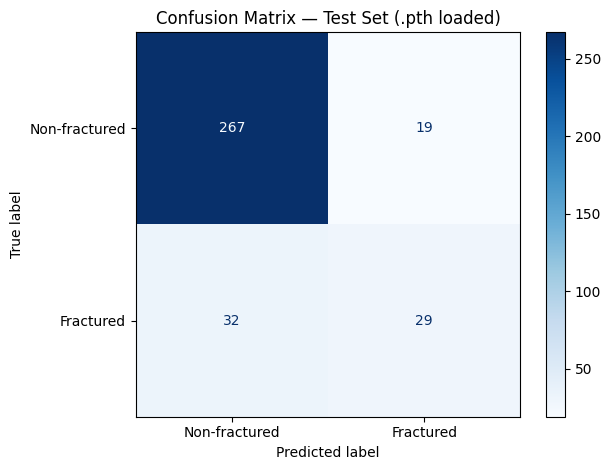

In [16]:
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Set this to the checkpoint you want to evaluate
checkpoint_path = Path("../weights/finetunedNN_2.0.pth")

if not checkpoint_path.exists():
    raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

ckpt = torch.load(checkpoint_path, map_location=device)
state_dict = ckpt["state_dict"] if isinstance(ckpt, dict) and "state_dict" in ckpt else ckpt
model.load_state_dict(state_dict)

model = model.to(device)
model.eval()
print(f"Loaded checkpoint: {checkpoint_path}")

test_accuracy = BinaryAccuracy().to(device)
test_precision = BinaryPrecision().to(device)
test_recall = BinaryRecall().to(device)
test_f1 = BinaryF1Score().to(device)

all_test_labels = []
all_test_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device).long()

        logits = model(images).flatten()
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.40).long()

        test_accuracy.update(preds, labels)
        test_precision.update(preds, labels)
        test_recall.update(preds, labels)
        test_f1.update(preds, labels)

        all_test_labels.extend(labels.cpu().numpy())
        all_test_preds.extend(preds.cpu().numpy())

print("Test Results (Loaded .pth)")
print(f"Accuracy : {test_accuracy.compute().item():.4f}")
print(f"Precision: {test_precision.compute().item():.4f}")
print(f"Recall   : {test_recall.compute().item():.4f}")
print(f"F1-score : {test_f1.compute().item():.4f}")

print("\nClassification Report:")
print(classification_report(all_test_labels, all_test_preds, target_names=["Non-fractured", "Fractured"]))

cm = confusion_matrix(all_test_labels, all_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-fractured", "Fractured"] )
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Test Set (.pth loaded)")
plt.tight_layout()
plt.show()